# 대응분석으로 브랜드 인식 매핑하기 (PROC CORRESP)

## 요약

한 시장조사 팀이 네 개의 기성 스트리밍 미디어 브랜드를 대상으로 브랜드별 속성 인식 설문을 실시하고, **PROC CORRESP**를 사용해 그 결과 교차표를 2차원 인식 지도로 변환합니다. 브랜드 x 속성 연관성은 강하고 실재합니다. 독립성 카이제곱 검정은 자유도 15에서 **63.15 (p < 0.0001)**이며, **Cramer's V = 0.4588**입니다. 대응분석은 그 연관성을 두 축으로 압축하며, 두 축이 합쳐서 표 관성(inertia)의 **100%**를 설명합니다 — 차원 1에서 **75.0%**, 차원 2에서 **25.0%** — 따라서 2차원 지도는 완전하고 충실한 요약입니다.

이 지도는 **프리미엄 콘텐츠** 극(CineNow, *오리지널 콘텐츠*와 *콘텐츠 깊이*에 고정됨)을 **가치/신뢰성** 군집(Streamly와 BingeBox가 *가성비*과 *신뢰성* 근처에 위치)과 **트렌디** 코너(PixelPlay가 *트렌디* 근처에 위치)로부터 분리합니다. 이어서 신흥 도전자인 **NovaCast**를 *보조(supplementary)* 점으로 투영합니다 — 이 점은 축에 영향을 주지 않습니다 — 그리고 원점 근처에 위치하며 트렌디 / 사용 편의성 쪽으로 약간 치우칩니다. 즉, 아직 차별화되지 않은 신규 진입자입니다.

## 데이터 소스

| 데이터셋 | 행 수 | 주요 변수 | 설명 |
|---------|------|---------------|-------------|
| `perception` | 100 (응답자 x 속성 연관, 비라이선스 모드 상한) | `Brand` (문자), `Attribute` (문자) | 합성 설문: 각 응답자가 여섯 개 속성 각각에 대해 가장 연관 짓는 스트리밍 브랜드를 지목합니다. 브랜드 선호는 `RAND("Table", ...)` 범주 확률로 인코딩되어 분할표가 현실적이고 비균일한 연관성을 갖습니다. |
| `survey_counts` | 24 (브랜드 4개 x 속성 6개) | `Brand`, `Attribute`, `Count` | PROC FREQ를 통해 `perception`에서 사전 집계한 분할표 셀 — 보조 점 CA 실행의 가중 입력. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | PROC CORRESP가 작성한 `OUTC=` 좌표 데이터셋. 두 번째 데이터셋은 투영된 NovaCast 점을 추가하며 인식 지도를 구동합니다. |

기성 브랜드: **Streamly, PixelPlay, CineNow, BingeBox**; 도전자 **NovaCast** (보조 점으로 투영됨). 속성: 가성비, 콘텐츠 깊이, 사용 편의성, 오리지널 콘텐츠, 신뢰성, 트렌디. 시드 `streaminit(20260531)`으로 데이터를 재현 가능하게 만듭니다.

> **표본 크기에 대한 주의.** 이 환경은 비라이선스로 실행되므로 DATA 스텝 출력이 100개 관측치로 제한됩니다. 따라서 설문은 총 100개의 응답자-속성 연관을 갖는 4x6 분할표로 귀결됩니다 — 작지만 대응분석이 깔끔하게 복원하는 진짜 연관 구조(카이제곱 p < 0.0001)를 지니고 있습니다.

## 대응분석이 여기서 하는 일

브랜드 추적 설문이 소비자에게 여러 속성 각각에 대해 어떤 브랜드를 가장 연관 짓는지 물으면, 그 결과는 **브랜드 x 속성 분할표**가 됩니다. 원시 빈도는 읽기 어렵습니다: 모든 브랜드가 모든 속성과 비교되며, 신호는 셀 값이 아니라 *연관의 패턴*입니다.

대응분석(CA)은 표의 카이제곱 연관성을 저차원 공간으로 분해하여, 서로 연관된 브랜드와 속성이 하나의 지도에서 가까이 위치하도록 합니다. 이 노트북에서는 다음을 수행합니다:

1. 네 개 스트리밍 브랜드에 대한 합성 인식 설문을 생성합니다.
2. `PROC FREQ`로 원시 분할 구조(및 카이제곱)를 점검합니다.
3. 전체 진단과 함께 `PROC CORRESP`를 실행하고 실제 관성과 좌표를 읽습니다.
4. 신흥 도전자 브랜드를 **보조** 점으로 투영합니다.
5. 그 결과 인식 지도를 그리고 해석합니다.

## 1단계 — 합성 인식 설문 생성

설문 응답자를 시뮬레이션합니다. 각 응답자에게 여섯 개 속성 각각에 대해 *이 속성과 가장 연관 짓는 브랜드는 무엇인가?*를 묻습니다. 각 브랜드는 고유한 **선호 프로파일** — `RAND("Table", ...)`에 전달되는 범주 확률 벡터 — 을 가지므로, 예를 들어 *PixelPlay*는 트렌디 쪽으로 치우치는 반면 *CineNow*는 콘텐츠 깊이와 오리지널 콘텐츠 쪽으로 치우칩니다. 이는 CA가 복원할 진짜이며 비균일한 연관성을 갖는 분할표를 만들어냅니다. 데이터는 완전히 합성되었으며 `CALL STREAMINIT`을 통해 재현 가능합니다.

In [1]:
데이터 perception;
    /* 재현 가능한 합성 브랜드 인식 설문 */
    호출 streaminit(20260531);

    길이 Brand $9 Attribute $30;

    n_resp = 400;

    반복 respondent = 1 까지 n_resp;
        반복 a = 1 까지 6;
            /* 속성 이름(한국어). 비ASCII 문자열은 _temporary_ 배열
               초기화에서 공백이 될 수 있으므로 if/else로 배정한다. */
            만약      a = 1 이면 Attribute = '가성비';
            아니면 만약 a = 2 이면 Attribute = '콘텐츠 깊이';
            아니면 만약 a = 3 이면 Attribute = '사용 편의성';
            아니면 만약 a = 4 이면 Attribute = '오리지널 콘텐츠';
            아니면 만약 a = 5 이면 Attribute = '신뢰성';
            아니면              Attribute = '트렌디';

            /* 속성별 브랜드 선택 확률(네 개 기성 브랜드):
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               각 행의 합은 ~1이며 그 속성의 브랜드 친화도를 인코딩한다. */
            만약      a = 1 이면 b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* 가성비         */
            아니면 만약 a = 2 이면 b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* 콘텐츠 깊이    */
            아니면 만약 a = 3 이면 b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* 사용 편의성    */
            아니면 만약 a = 4 이면 b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* 오리지널 콘텐츠 */
            아니면 만약 a = 5 이면 b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* 신뢰성         */
            아니면              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* 트렌디         */

            선택 (b);
                경우 (1) Brand = 'Streamly';
                경우 (2) Brand = 'PixelPlay';
                경우 (3) Brand = 'CineNow';
                기타 Brand = 'BingeBox';
            종료;

            출력;
        종료;
    종료;

    유지 respondent Brand Attribute;
실행;

처리 인쇄 데이터=perception(obs=8) noobs;
    제목 '합성 인식 설문 표본';
실행;

                                                      합성 인식 설문 표본                                                       

respondent      Brand               Attribute
         1  BingeBox   가성비
         1  BingeBox   콘텐츠 깊이
         1  BingeBox   사용 편의성
         1  CineNow    오리지널 콘텐츠
         1  Streamly   신뢰성
         1  PixelPlay  트렌디
         2  PixelPlay  가성비
         2  CineNow    콘텐츠 깊이

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.41 seconds
  cpu   0.41 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## 2단계 — 원시 분할표 점검

차원 축소를 하기 전에 교차표를 살펴봅니다. `PROC FREQ`는 관측된 브랜드 x 속성 빈도와 독립성 카이제곱 검정을 제공합니다. 유의한 카이제곱은 지도로 그릴 만한 연관 구조가 있음을 확인해 줍니다 — 만약 행과 열이 독립이라면 대응분석은 보여줄 것이 없습니다. 또한 나중의 보조 점 CA 실행을 위해 셀 빈도를 `survey_counts`에 저장합니다.

                                                    관측된 브랜드 x 속성 빈도                                                     

                                                   The FREQ Procedure

Table of Brand by Attribute

Brand     |                   가성비 |                사용 편의성 |                   신뢰성 |              오리지널 콘텐츠 |                콘텐츠 깊이 |                   트렌디 |                  Total
----------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
BingeBox  |                     5 |                     7 |                     6 |                     1 |                     3 |                     2 |                     24
----------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
CineNow   |                     3 |                     0 |   


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


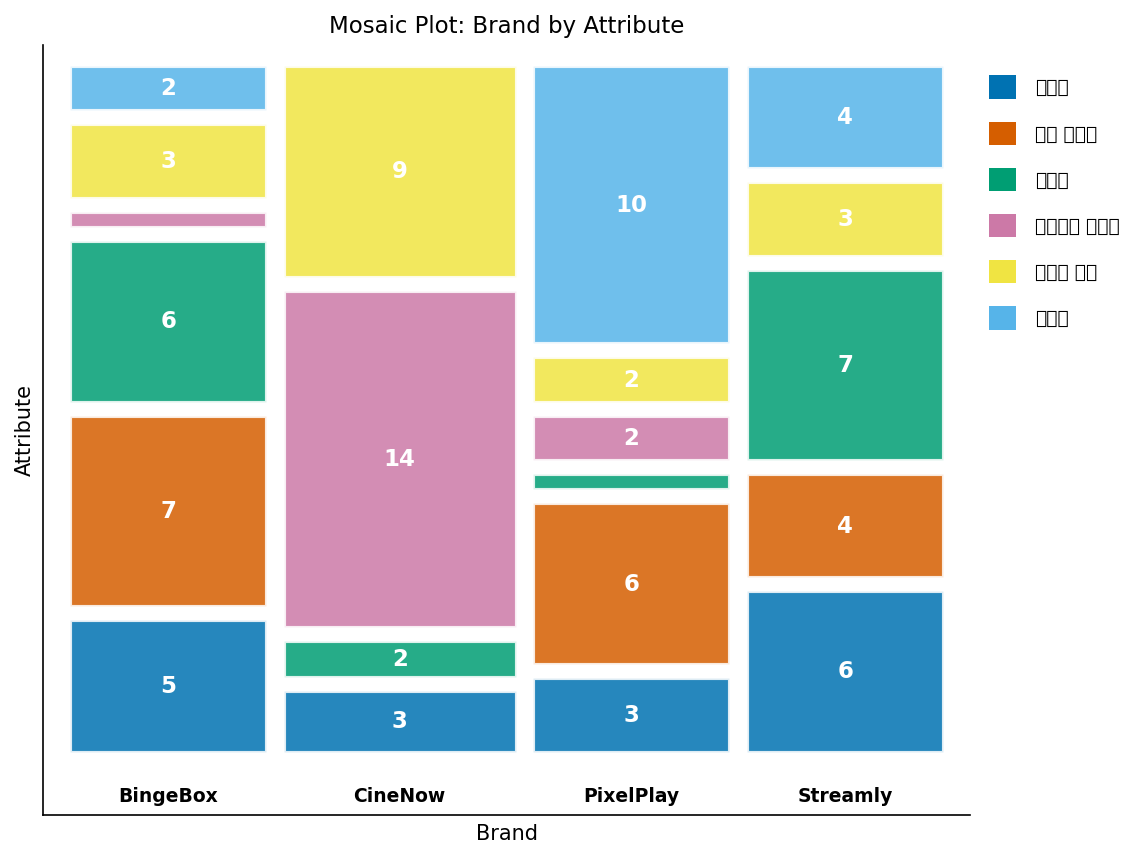

In [2]:
처리 빈도 데이터=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(개명=(count=Count));
    제목 '관측된 브랜드 x 속성 빈도';
실행;

## 3단계 — 원시 데이터로부터의 대응분석

이제 응답자 수준 데이터에 직접 `PROC CORRESP`를 실행합니다. `TABLES Brand, Attribute;`는 내부적으로 분할표를 구성합니다(브랜드는 행, 속성은 열).

여기서 사용한 옵션:

- `ALL` — 전체 진단을 출력: 관측된 표, 프로파일, 기댓값, 그리고   셀 카이제곱 기여도.
- `DIMENS=2` — 처음 두 개 주축을 계산(2차원 지도).
- `OUTC=` — 플롯을 위해 행과 열 좌표를 데이터셋에 작성.

**관성 분해**는 각 축이 전체 연관성 중 얼마를 설명하는지 알려줍니다.

In [3]:
처리 corresp 데이터=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    제목 '대응분석: 스트리밍 브랜드 인식';
실행;

                                                    관측된 브랜드 x 속성 빈도                                                     

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## 4단계 — 좌표 읽기

`OUTC=` 데이터셋은 모든 브랜드와 속성에 대한 축 좌표(`Dim1`, `Dim2`)를 담고 있으며, `_TYPE_`으로 태그가 붙습니다(브랜드는 `ROW`, 속성은 `COLUMN`). 이를 관성 표와 나란히 수치로 읽으면 지도가 보여줄 구조가 확인됩니다.

위 출력으로부터:

- **차원 1 (관성의 75.0%)**은 *프리미엄 콘텐츠 대 주류* 축입니다.   *오리지널 콘텐츠* (Dim1 = -1.2037)와 *콘텐츠 깊이* (-0.5594)는 음의 끝에   **CineNow** (-1.0847)와 함께 위치하며, *트렌디* (0.6671), *사용 편의성* (0.6150),   *가성비* (0.2207)은 양의 끝에 위치합니다.
- **차원 2 (관성의 25.0%)**은 *신뢰성* (Dim2 = 0.5874)과   *가성비* (0.2542) — **Streamly** (0.3207)와 **BingeBox** (0.3555)를 끌어올림 —   을 *트렌디* (-0.7003)로부터 분리하며, 후자는 **PixelPlay** (-0.6374)를 끌어내립니다.

In [4]:
처리 인쇄 데이터=ca_coords noobs label;
    변수 _TYPE_ _NAME_ Dim1 Dim2;
    라벨 _TYPE_='유형' _NAME_='점 이름' Dim1='차원 1' Dim2='차원 2';
    제목 '행(브랜드)과 열(속성) 좌표';
실행;

                                                    행(브랜드)과 열(속성) 좌표                                                    

    유형                                    점 이름      차원 1      차원 2
ROW     BingeBox                                  0.3547    0.3555
ROW     CineNow                                  -1.0847   -0.0332
ROW     PixelPlay                                 0.4804   -0.6374
ROW     Streamly                                  0.4304    0.3207
COLUMN  가성비                                       0.2207    0.2542
COLUMN  사용 편의성                                    0.6150   -0.0080
COLUMN  신뢰성                                       0.3183    0.5874
COLUMN  오리지널 콘텐츠                                 -1.2037   -0.2084
COLUMN  콘텐츠 깊이                                   -0.5594    0.0684
COLUMN  트렌디                                       0.6671   -0.7003




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## 5단계 — 도전자 브랜드를 보조 점으로 투영

분석 팀은 신흥 도전자 **NovaCast**의 추적 데이터를 가지고 있지만, 그것이 기성 인식 지도를 왜곡하기를 원하지 않습니다. *보조* 점은 **축 계산에 기여하지 않고** 기존 CA 공간으로 투영됩니다.

사전 집계된 `survey_counts`에 NovaCast의 여섯 개 속성 빈도로 이루어진 단일 블록(트렌디 / 오리지널 콘텐츠 쪽으로 치우친 신규 진입자)을 덧붙이고, `WEIGHT Count`로 빈도를 공급하며, `SUPPLEMENTARY` 문에서 **수준(level)** 이름을 `NovaCast`로 지정하여 PROC CORRESP가 그 행을 활성 표에서 제외하도록 합니다. `OBSERVED` 옵션은 활성 분할표(합이 100인 네 개 기성 브랜드)를 계속 보이게 유지합니다 — NovaCast는 거기에 **나타나지 않음**에 유의하십시오. 이는 그것이 보조로 처리되었음을 확인해 줍니다.

In [5]:
/* 집계된 셀에 NovaCast 카운트 한 블록을 덧붙인다.
   end=last는 survey_counts의 마지막 행 이후 정확히 한 번 실행되어
   NovaCast가 (속성당 한 행씩) 여섯 행을 기여하게 한다 -- 중복 블록이
   아니다. NovaCast는 트렌디 / 오리지널 콘텐츠 주도의 신규 진입자다. */
데이터 survey_counts_sup;
    설정 survey_counts 종료=last;
    출력;
    만약 last 이면 반복;
        Brand='NovaCast'; Attribute='트렌디';          Count=10; 출력;
        Brand='NovaCast'; Attribute='오리지널 콘텐츠';  Count=8;  출력;
        Brand='NovaCast'; Attribute='사용 편의성';      Count=5;  출력;
        Brand='NovaCast'; Attribute='콘텐츠 깊이';      Count=3;  출력;
        Brand='NovaCast'; Attribute='가성비';           Count=4;  출력;
        Brand='NovaCast'; Attribute='신뢰성';           Count=3;  출력;
    종료;
실행;

처리 corresp 데이터=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    가중 Count;
    supplementary NovaCast;
    제목 'NovaCast를 보조 점으로 한 브랜드 인식';
실행;

                                                    행(브랜드)과 열(속성) 좌표                                                    

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## 6단계 — 인식 지도 그리기

PROC CORRESP는 대칭적 행/열 좌표를 `OUTC=` 데이터셋에 작성합니다. 우리는 차원 1에 대해 차원 2를 플롯하여 지도를 렌더링합니다. 각 점을 **역할**로 태그합니다 — *Brand* (활성 행), *Attribute* (열), *Challenger* (보조 NovaCast 행) — 그리고 모든 마커에 레이블을 붙여 위치를 플롯에서 직접 읽을 수 있게 합니다. 도전자는 별도 색으로 표시하여 그것이 적합화된 것이 아니라 투영된 것임을 강조합니다.

> **CA 지도 읽는 법.** 원점으로부터 같은 방향에 (그리고 원점에서 멀리) 위치한 브랜드와 속성은 강하게 연관되어 있습니다. 원점 근처의 점들은 "평균적"이며 약하게 차별화됩니다. 차원 1과 2가 합쳐서 이 표 관성의 100%를 포착하므로, 이 지도는 아무것도 누락하지 않습니다.

                                        스트리밍 브랜드 인식 지도 (차원1 관성 75.0%, 차원2 25.0%)                                        

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, 차원 1 (관성의 75.0%), 차원 2 (관성의 25.0%)

      Role      _NAME_            차원 1 (관성의 75.0%)            차원 2 (관성의 25.0%)
----------  ----------  --------------------------  --------------------------
       브랜드    BingeBox                      0.3547                      0.3555
       브랜드     CineNow                     -1.0847                     -0.0332
       브랜드   PixelPlay                      0.4804                     -0.6374
       브랜드    Streamly                      0.4304                      0.3207
       도전자    NovaCast                      0.0084                     -0.1735
        속성         가성비                      0.2207                      0.2542
        속성      사용 편의성                       0.615                      -0.008
        속성         신뢰성                      0.3183                    


NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to 스트리밍 브랜드 인식 지도 (차원1 관성 75.0%, 차원2 25.0%).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


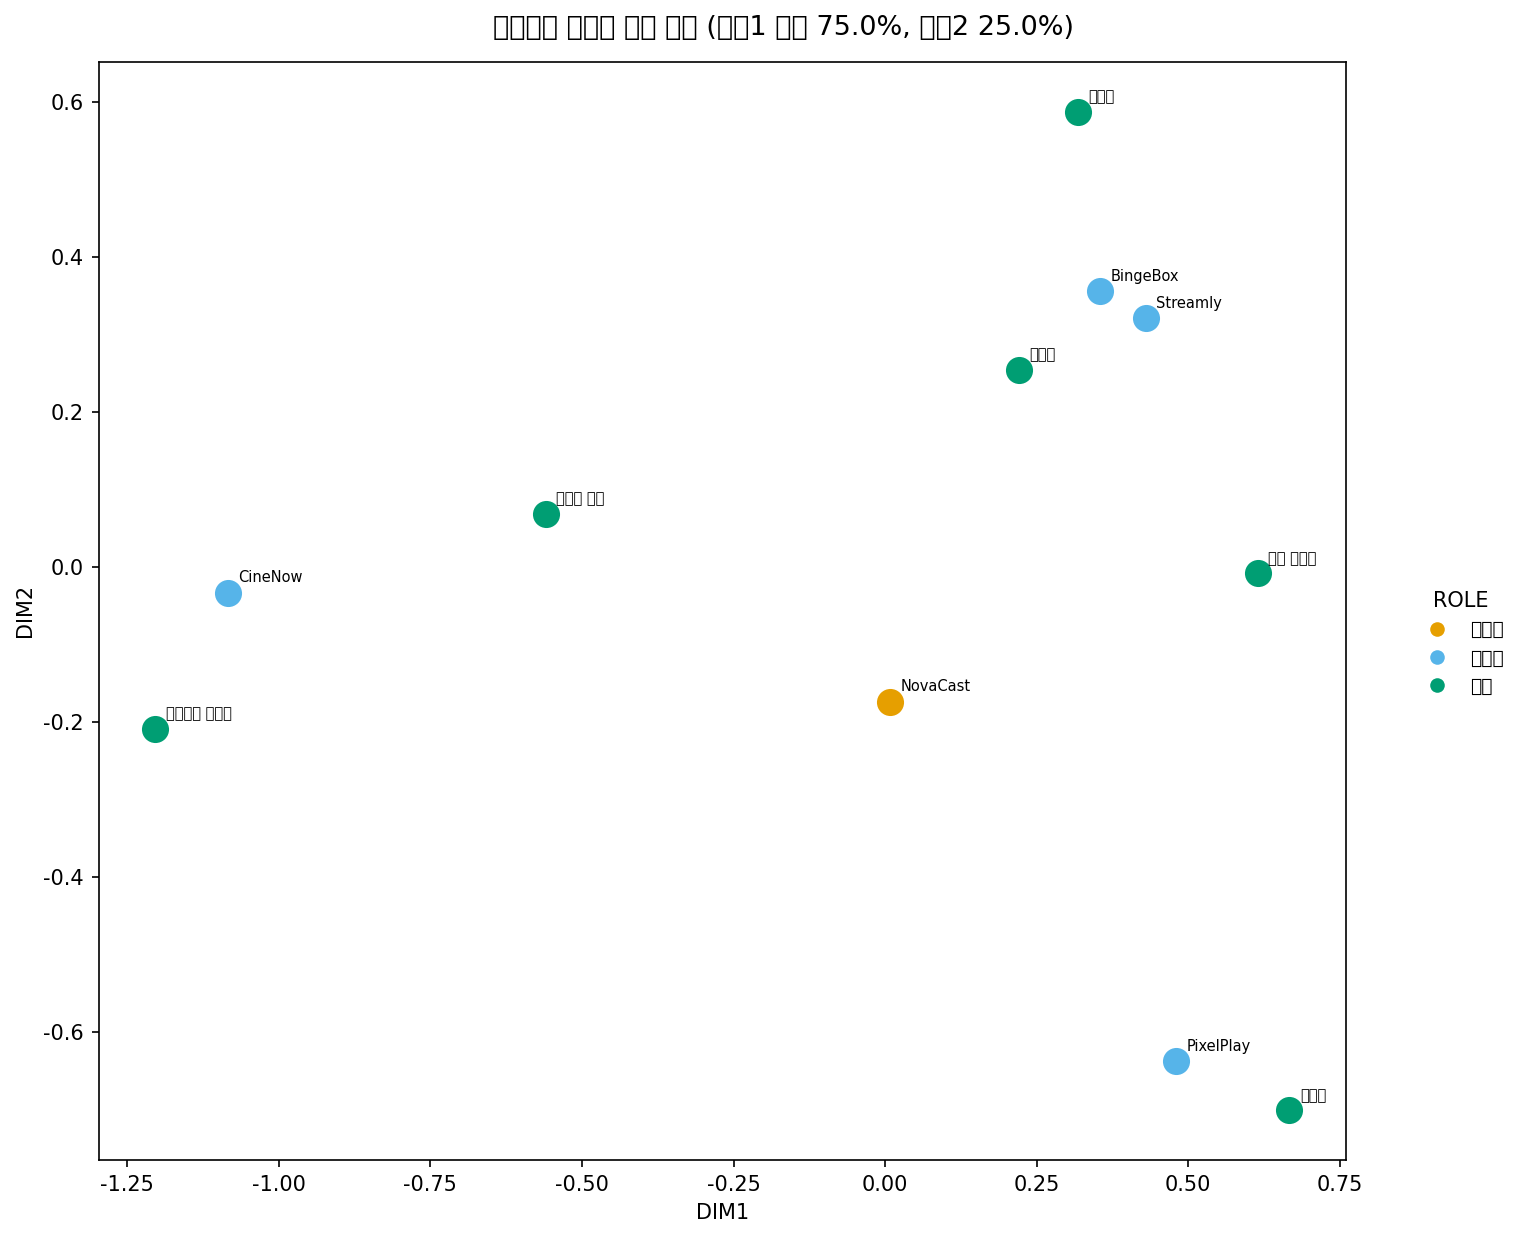

In [6]:
/* 깔끔한 색상 범례를 위해 각 OUTC 점을 역할로 태그한다.
   보조 NovaCast는 OUTC에 _TYPE_='ROW'로 기록되므로 도전자로
   특수 처리한다. */
데이터 ca_map;
    설정 ca_coords_sup;
    길이 Role $12;
    만약 _NAME_ = 'NovaCast' 이면 Role = '도전자';
    아니면 만약 _TYPE_ = 'ROW' 이면 Role = '브랜드';
    아니면 Role = '속성';
    라벨 Dim1='차원 1 (관성의 75.0%)' Dim2='차원 2 (관성의 25.0%)';
    유지 Role _NAME_ Dim1 Dim2;
실행;

/* PROC 앞에서 지도의 제목을 전역으로 설정하여 이 플롯의 제목이 되게
   한다(전역 TITLE이 ODS 그래픽의 헤딩을 구동한다). */
제목 '스트리밍 브랜드 인식 지도 (차원1 관성 75.0%, 차원2 25.0%)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* 이 빌드의 PROC CORRESP에는 네이티브 ODS 지도가 없으므로, 각 점에
   레이블을 붙이는 PROC SGSCATTER로 대칭 좌표를 렌더링한다. */
처리 SGSCATTER 데이터=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
실행;

ODS GRAPHICS OFF;
제목;

## 결과 해석

**연관성은 실재하며 완전히 포착되었습니다.** 카이제곱 검정(자유도 15에서 63.15, p < 0.0001; Cramer's V = 0.4588)은 독립성을 기각하며, 두 CA 차원이 표 관성의 **100%**(75.0% + 25.0%)를 설명하므로 아래 지도는 손실 있는 투영이 아니라 완전한 요약입니다.

**세 개의 인식 영역.** 좌표와 지도를 함께 읽으면:

- **프리미엄 콘텐츠 (왼쪽).** *CineNow* (Dim1 = -1.0847)는   *오리지널 콘텐츠* (-1.2037)와 *콘텐츠 깊이* (-0.5594)에 의해 왼쪽 멀리 끌려가며 —   카탈로그 깊이 인식을 장악합니다.
- **가치 & 신뢰성 (오른쪽 위).** *Streamly* (0.4304, 0.3207)와 *BingeBox*   (0.3547, 0.3555)는 *가성비* (0.2207, 0.2542) 및 *신뢰성* (0.3183,   0.5874)과 군집을 이룹니다 — 믿을 만하고 가성비 좋은 짝입니다.
- **트렌디 (오른쪽 아래).** *PixelPlay* (0.4804, -0.6374)는 *트렌디*   (0.6671, -0.7003) 옆에 위치합니다 — 젊고 지금 이 순간의 브랜드입니다.

**보조 도전자.** 축에 영향을 주지 않고 투영된 **NovaCast**는 (0.0084, -0.1735)에 위치합니다 — 본질적으로 원점에 있으며 트렌디 / 사용 편의성 쪽으로 살짝 밀려 있습니다. 미디어 전략가에게 이것이 핵심 메시지입니다: 도전자는 아직 뚜렷한 자산이 없고 PixelPlay의 트렌디 영역으로 흘러들고 있으므로, (모방형이 아닌) 차별화된 포지셔닝이 요구됩니다.

**유의사항.** 대응분석은 추론적이 아니라 기술적입니다 — 거리는 근사값이며 축 *부호*는 임의적입니다(어느 한 축을 거울처럼 뒤집어도 같은 지도입니다). 단 100개의 응답자-속성 연관만으로는 두 셀이 0이며(CineNow x 사용 편의성, Streamly x 오리지널 콘텐츠), 이것이 극단을 더 날카롭게 만듭니다. 실제 연구라면 더 큰 표본을 조사할 것입니다. 표시된 차원이 얼마나 많은 연관성을 설명하는지 확인하려면 항상 지도를 관성 표와 함께 살펴보십시오.